# Notebook 5.1: Convolutions

In this notebook we will explore the 2D convolution and cross-correlation operations on an image of a cat.

In [7]:
!curl -L "https://www.dropbox.com/scl/fi/vc3j08yctlosvpr57v2ot/cat.jpg?rlkey=nbgc9klg8wlgkfewk08ln72xf&dl=1" -o cat.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100    17  100    17    0     0     51      0 --:--:-- --:--:-- --:--:--    51

100  112k  100  112k    0     0   167k      0 --:--:-- --:--:-- --:--:--  167k


In [8]:
from imageio.v3 import imread, imwrite
from skimage.transform import rescale
from scipy.ndimage import convolve, correlate
from skimage.color import rgb2gray
from matplotlib import pyplot as plt
import numpy as np

Let's first load the cat image using `imageio.imread`.

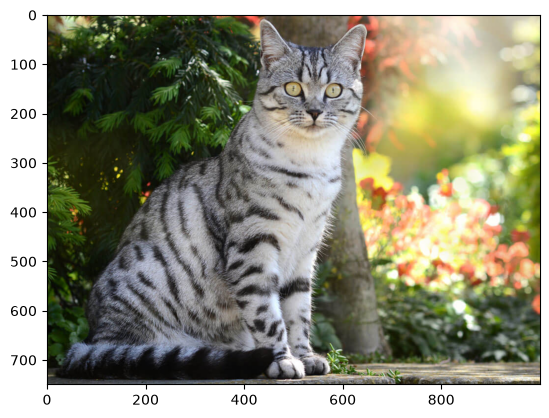

In [9]:
img = imread('cat.jpg')
plt.imshow(img)

The shape of the image is (H,W,C) -- height, width, channels -- and the data type is 8-bit unsigned integer.

In [10]:
img.shape, img.dtype

((750, 1000, 3), dtype('uint8'))

In [11]:
img[0,0]

array([132,  97,  43], dtype=uint8)

Let's resize the image so it is a bit easier to work with.

In [12]:
img = rescale(img, 0.5, anti_aliasing=True, channel_axis=-1)

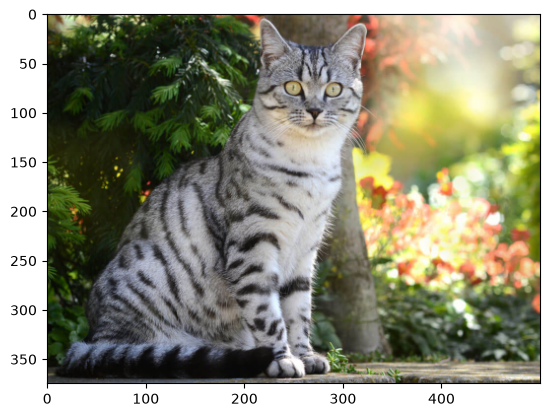

In [13]:
plt.imshow(img)
plt.show()

In [14]:
img.shape, img.dtype

((375, 500, 3), dtype('float64'))

In [15]:
img[0,0]

array([0.52809619, 0.40359118, 0.17732866])

Now let's convert to grayscale.

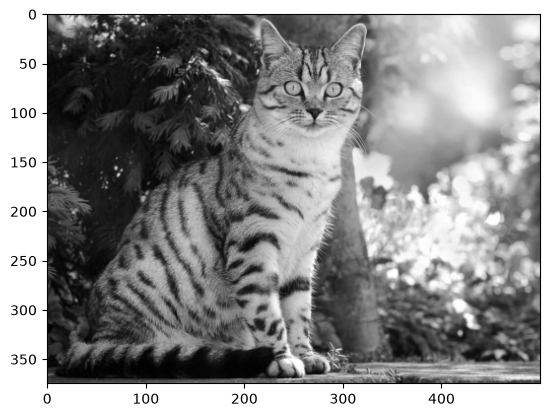

In [16]:
gray = rgb2gray(img)
plt.imshow(gray,cmap='gray')

Now the image has a single channel and is in 32-bit floating point.

In [17]:
gray.shape, gray.dtype

((375, 500), dtype('float64'))

In [18]:
gray[0,0]

np.float64(0.41373496800903686)

## Applying convolutional filters

Let's make a vertical edge filter as described in class.

In [19]:
dIdx = np.array([[-1, 0, 1]])

(np.float64(-0.5), np.float64(2.5), np.float64(0.5), np.float64(-0.5))

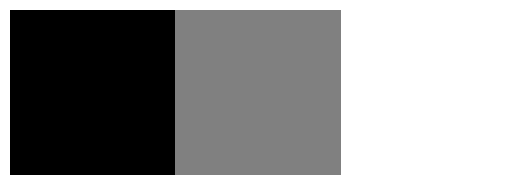

In [20]:
plt.imshow(dIdx,cmap='gray')
plt.axis('off')

To apply it to the image, we can use either `convolve` or `correlate`.

In [21]:
dIdx_convolve = convolve(gray,dIdx)
dIdx_correlate = correlate(gray,dIdx)

Text(0.5, 1.0, 'Correlation')

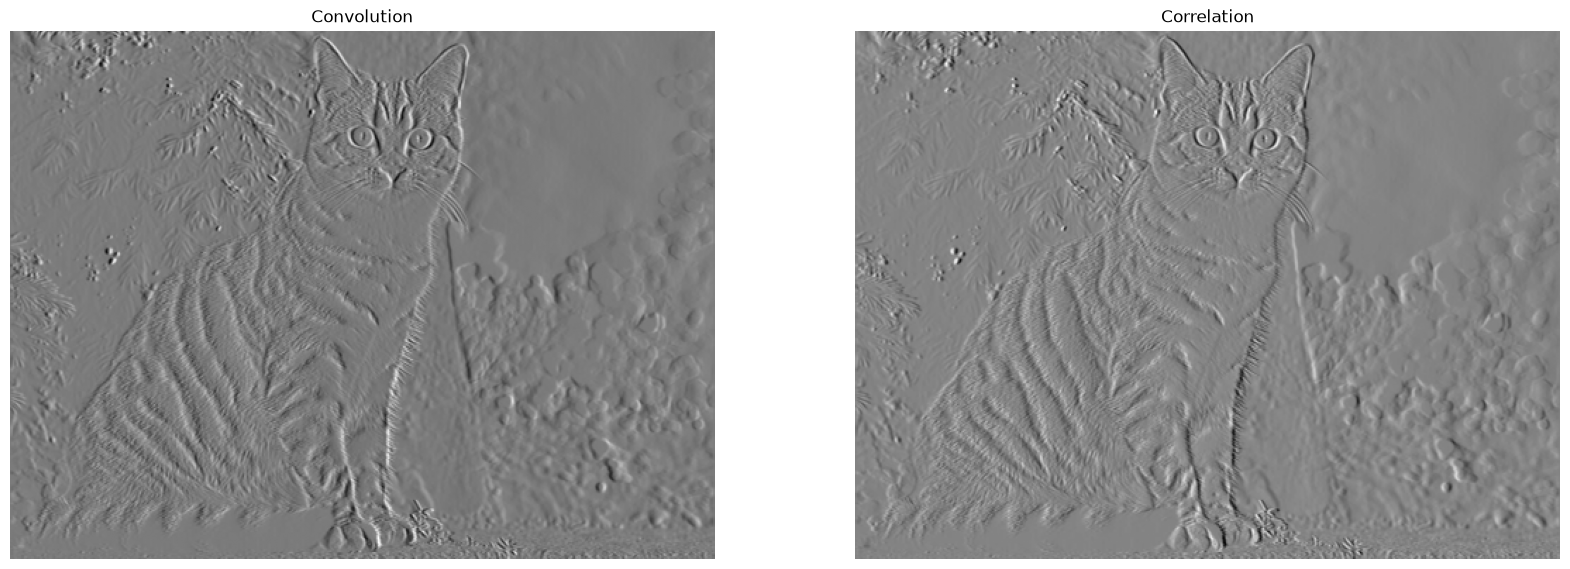

In [22]:
fig,axes = plt.subplots(1,2,figsize=(20,10))
axes[0].imshow(dIdx_convolve,cmap='gray')
axes[0].axis('off')
axes[0].set_title('Convolution')
axes[1].imshow(dIdx_correlate,cmap='gray')
axes[1].axis('off')
axes[1].set_title('Correlation')

Looking at the top left corner of the filter responses:

In [23]:
dIdx_convolve[:3,:3]

array([[-0.07364572, -0.10083385,  0.01049286],
       [-0.05640436, -0.09539044, -0.03540619],
       [-0.04607864, -0.09251003, -0.06271954]])

In [24]:
dIdx_correlate[:3,:3]

array([[ 0.07364572,  0.10083385, -0.01049286],
       [ 0.05640436,  0.09539044,  0.03540619],
       [ 0.04607864,  0.09251003,  0.06271954]])

The filter responses are equal but flipped in sign.  This is because the convolution operation horizontally and vertically flips the filter before applying it.  In this case, the horizontally flipped filter is a negated version of the original.